/tmp/ipykernel_1012417/3476371398.py:139: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  timing.legend(loc='upper left')


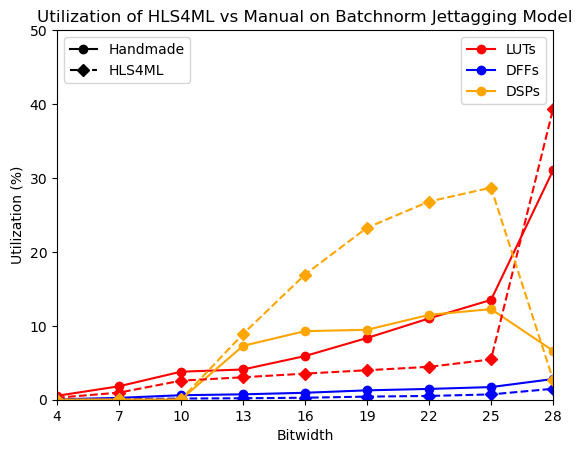

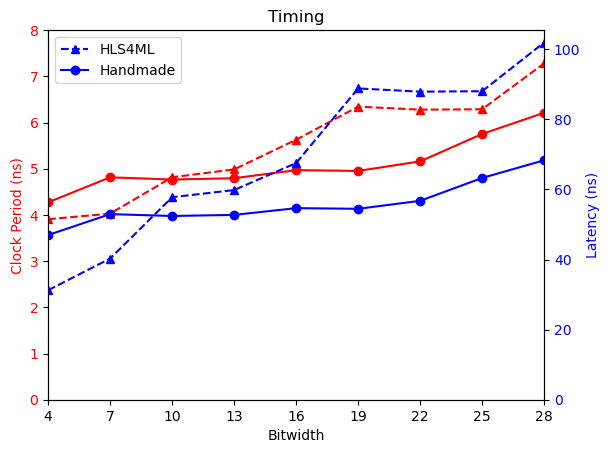

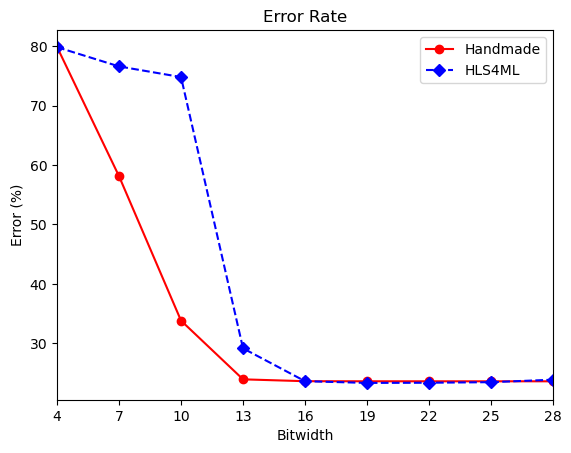

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
legend_lines = []
hand_lat = [23, 19, 16]
resf, res = plt.subplots()

timingf, timing = plt.subplots()

accf, acc = plt.subplots()
# latf, lat = plt.subplots()
lat = timing.twinx()

marker_styles = [None,'o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'H', '+', 'x', '|', '_']
line_styles = ['-', '--', '-.', ':']
colors = ['r','b',(255.0/255,165.0/255,0),'c','m','g']
j=[0, 1]
timings = []
renames = {"SliceRegisters":"DFFs", "SliceLUTs":"LUTs"}
# colorkey = {"LUTs":'r', "DFFs": 'y', "DSPs": }
def plot_res(file, ls, name, marker, color_sel=None):
    resources = pd.read_csv(file)
    x_val = resources["Bits"]
    all_res_hand = []
    Nono = "Bits Accuracy Timing BondedIOB CycleLatency TotalLatency BlockRAMTile"
    i=0
    # timings.append((resources["Timing"], name))
    # timing.plot(x_val, 5-resources["Timing"], label=name, linestyle=ls, color=colors[j[0]], marker=marker)
    acc.plot(x_val, (1-resources["Accuracy"])*100, label=name, linestyle=ls, color=colors[j[0]], marker=marker)
    j[0]=(j[0]+1)%len(colors)
    for key in resources:
        if (key not in Nono):
            all_res_hand.append(resources[key])
            nam = key if key not in renames else renames[key]
            res.plot(x_val, 
            resources[key], 
            label=(nam if len(legend_lines)==0  else None), 
            linestyle=ls, 
            color=colors[i] if color_sel==None else color_sel,
            marker=marker)
            i+=1
            
    legend_lines.append((name, ls, marker,color_sel))

# plot_res(f"handmade/Results/util_SA3.csv", line_styles[0], 
# f"Depth 3.0",marker_styles[0]
# )
# for i in range(2,10,2):
#     i_linestyle=(int(i/2))%len(line_styles)
#     i_marker=int((int(i/2))/len(line_styles))
#     plot_res(f"handmade/Results/util_SA3_{i}.csv", 
#     line_styles[i_linestyle], 
#     f"Depth 3.{i}",
#     marker_styles[i_marker]
#     # ,colors[(int((i)/2))%len(colors)]
#     )
# plot_res(f"handmade/Results/util_SA4.csv", line_styles[2], f"Depth 4.0",marker_styles[1]
# )
# plot_res("handmade/Results/util_Argmax_varpipes.csv", '-', "Optimized SA",marker_styles[0] )
# plot_res("handmade/Results/util_perf.csv", '--', "Old Optimized SA",marker_styles[0] )
# plot_res("handmade/Results/util_Argmax_pipe3PO0.csv", '-', "pipe3",marker_styles[0] )
# plot_res("handmade/Results/util_Argmax_P1_PO0_SA2_MULTPIPE1.csv", '-', "M1",marker_styles[1] )
# plot_res("handmade/Results/util_Argmax_P1_PO0_SA2_MULTPIPE.csv", '-.', "M0",marker_styles[1] )
plot_res("handmade/Results/util_expPipeNegmax.csv", '-', "Handmade",marker_styles[1] )
# plot_res("handmade/Results/util_my_mult.csv", '-', "Handmade",marker_styles[1] )
# plot_res("handmade/Results/util_Argmax_P1_PO1.csv", ':', "pipe1po1",marker_styles[1] )
# plot_res("handmade/Results/util_Argmax_P1_PO0_SA2.csv", ":","NORM", marker_styles[0])
plot_res("hls4ml/results/util_hls_please.csv", '--', "HLS4ML",marker_styles[3] )
# plot_res("hls4ml/results/util_hls_reuse5.csv", '-', "HLS4ML R5",marker_styles[3] )
# plot_res("../util_norm_op.csv", ':', "Op norm")
# plot_res("../Results/util_SA2.csv", '-.', "SA2",marker_styles[0])
# plot_res("handmade/Results/util_SA2.csv", '-.', "SA2", marker_styles[0])
#plot_res("../util_SA4.csv", '--', "SA4",marker_styles[0])
#plot_res("../util_SA6.csv", '-', "SA6",marker_styles[4])
# plot_res("../util_SA3_6.csv", ':', "SA3.6",marker_styles[1])
# plot_res("../util_SA3_8.csv", '--', "SA3.8",marker_styles[1])
# plot_res("../util_SA4.csv", '-', "SA4",marker_styles[1])
#plot_res("../util_SA6.csv", ':', "SA6")
# plot_res("../Results/util_unop.csv", ':', "Handmade", marker_styles[0])
# plot_res("util_hls_new.csv", '--', "HLS4ML", marker_styles[0])
# plot_res("util_hls_fast.csv", '-.', "HLS4ML fast", marker_styles[0])
# plot_res("util_hls_final.csv", ':', "HLS4ML final", marker_styles[0])
# plot_res("util_hls_argmax.csv", '-', "HLS4ML argmax", marker_styles[0])
# latency = pd.read_csv("hls4ml/results/hls_latency.csv", delimiter = ", ")["Lat"]
# # print(latency)
csv_val = pd.read_csv("hls4ml/results/util_hls_please.csv")
total_latency= csv_val["TotalLatency"]
txval = csv_val["Bits"]
timingHLS = csv_val["Timing"]
total_period_hls = np.add(5, -timingHLS)
timing.plot(txval, total_period_hls, marker=marker_styles[4], linestyle='--', color = 'r')

# total_period = np.add(5, -tim)
# total_latency = np.multiply(latency, total_period)

lat.plot(txval, total_latency, label="HLS4ML", marker=marker_styles[4], linestyle='--', color = 'b')

hand = pd.read_csv("handmade/Results/util_my_mult.csv")
timinghand = hand["Timing"]
total_period_hand = np.add(5, -timinghand)
timing.plot(hand["Bits"], total_period_hand, marker=marker_styles[1], linestyle='-', color = 'r')
txval = hand["Bits"]

totaltHand = np.multiply(total_period_hand, hand["CycleLatency"])
lat.plot(txval[:len(totaltHand)], totaltHand, label="Handmade", marker=marker_styles[1], linestyle='-', color = 'b')

# txval = pd.read_csv("handmade/Results/util_expPipeNegmax.csv")["Bits"]
# timinghand = pd.read_csv("handmade/Results/util_expPipeNegmax.csv")[" Timing"]
# total_period_hand = np.add(5, -timinghand)
# totaltHand = np.multiply(total_period_hand, 11)
# lat.plot(txval[:len(totaltHand)], totaltHand, label="NEG")

# txval = pd.read_csv("handmade/Results/util_Argmax_P1_PO0_SA2_MULTPIPE.csv")["Bits"]
# timinghand = pd.read_csv("handmade/Results/util_Argmax_P1_PO0_SA2_MULTPIPE.csv")[" Timing"]
# total_period_hand = np.add(5, -timinghand)
# totaltHand = np.multiply(total_period_hand, 9)
# lat.plot(txval[:len(totaltHand)], totaltHand, label="Pipe3po0")

# txval = pd.read_csv("handmade/Results/util_Argmax_pipe3.csv")["Bits"]
# timinghand = pd.read_csv("handmade/Results/util_Argmax_pipe3PO1.csv")[" Timing"]
# total_period_hand = np.add(5, -timinghand)
# totaltHand = np.multiply(total_period_hand, 13)
# lat.plot(txval[:len(totaltHand)], totaltHand, label="Pipe3po1")




#print()

lat.legend(loc='upper left')
lat.set_xticks(np.arange(4, 40, 3))
lat.set_ylim(0)
lat.set_xlim((4,28))
# lat.set_title("Total Latency")
# lat.set_xlabel("Bitwidth")
lat.set_ylabel("Latency (ns)", color='b')
lat.tick_params(axis='y', labelcolor='b')

timing.legend(loc='upper left')
timing.set_title("Timing")
timing.set_xlabel("Bitwidth")
timing.set_ylabel("Clock Period (ns)", color='r')
timing.set_ylim((0,8))
timing.set_xticks(np.arange(4, 40, 3))
timing.set_xlim((4,28))

timing.tick_params(axis='y', labelcolor='r')


first_legend = res.legend(loc='upper right')
res.add_artist(first_legend)
lines = []
for line in legend_lines:
    l, = res.plot([], label=line[0], linestyle=line[1], marker=line[2], color=line[3] if line[3]!=None else (0,0,0))
    lines.append(l)
res.legend(handles=lines, loc='upper left')
res.set_title("Utilization of HLS4ML vs Manual on Batchnorm Jettagging Model")
res.set_xticks(np.arange(4, 40, 3))
res.set_xlim((4,28))
res.set_ylim((0,50))
res.set_xlabel("Bitwidth")
res.set_ylabel("Utilization (%)")


acc.legend(loc='upper right')
acc.set_title("Error Rate")
acc.set_xlabel("Bitwidth")
acc.set_ylabel("Error (%)")
acc.set_xticks(np.arange(4, 40, 3))
acc.set_xlim((4,28))



plt.show()


In [10]:
def comp(a, b):
    comps = [0.0]*len(a)
    for i in range(min(len(a),len(b))):
        comps[i]=b[i]/a[i]
    return np.round(np.average(comps),2)
def mklist(item):
    output = [0.0]*len(item)
    for i,item in enumerate(item):
        output[i]=item
    return output
res_hls = pd.read_csv("hls4ml/results/util_hls_please.csv")
res_hand = pd.read_csv("handmade/Results/util_expPipeNegmax.csv")


start=3
end=11

max_hls = np.max(np.stack((res_hls["SliceLUTs"],res_hls["DSPs"]), axis=1), axis=1)
max_hand = np.max(np.stack((res_hand["SliceLUTs"],res_hand["DSPs"]), axis=1), axis=1)
ratios = np.divide(max_hand[start:9], max_hls[start:])
max_ratio = np.min(ratios)
ind_rat = -1
print(ratios)
for i in range(len(ratios)):
    if ratios[i]==max_ratio:
        ind_rat=i
print(f"Max ratio {max_ratio} at {list(res_hls['Bits'])[start:][ind_rat]}")
print(f"Average max device resource: {comp(max_hls[start:end], max_hand[start:end])}")
# print(np.average(np.divide(max_hand[:9],max_hls)))
for key in res_hand:
    if (key not in "Bits BlockRAMTile Bits SliceRegisters Timing BondedIOB"):
        print(key + ": " + f"{comp(mklist(res_hls[key])[start:], mklist(res_hand[key])[start:])}")
        hand = mklist(res_hand[key])
        hls = mklist(res_hls[key])
        # print(f"{key}: HLS:{np.mean(hls[start:end])} Hand:{np.mean(hand[start:end])}")
        # comped = comp((res_hls[key]), (res_hand[key]))
        # print(f"Hand is {np.round(comped, 4)} higher than HLS at {key}")

[0.8200225  0.54781582 0.40653202 0.42819843 0.47054723 0.7889115 ]
Max ratio 0.406532015470563 at 19
Average max device resource: 0.58
SliceLUTs: 1.81
DSPs: 0.84
Accuracy: 1.01
CycleLatency: 0.83
TotalLatency: 0.73


In [3]:
import pandas as pd
content1 = pd.read_csv("handmade/Results/util_expPipeNegmax.csv")
content2 = pd.read_csv("handmade/Results/util_my_mult.csv")
content2["CycleLatency"] = content1["CycleLatency"]
content2["TotalLatency"] = ([11*(5-float(i)) for i in content2["Timing"]])
content2.to_csv("handmade/Results/util_my_mult.csv")

In [ ]:
import os
dir = "hls4ml/results"
files = os.listdir(dir)
for file in files:
    file = os.path.join(dir, file)
    f=open(file, "r")
    lines = f.readlines()
    if (len(lines)<3):
        os.remove(file)

In [1]:
import os
import shutil
dir = "hls4ml/reports"
files = os.listdir(dir)
for file in files:
    if ("please" in file):
        file = os.path.join(dir, file)
        shutil.move(file, file.replace("please", "final"))

In [12]:
mainFile = pd.read_csv("handmade/Results/util_expPipeNegmax.csv")
newFile = pd.read_csv("handmade/Results/expPipeNegmax_acc.csv")
mainFile["Accuracy"] = newFile["Accuracy"]
mainFile.to_csv("handmade/Results/util_expPipeNegmax.csv")

In [1]:
import numpy as np
def dec_to_bin(number: int, bits=-1):
    number=int(np.round(number, 0))
    neg=False
    out=""
    if (number<0):
        number*=-1
        number-=1
        neg=True
    while (number>0):
        res = number%2
        if (neg):
            res= 0 if (res==1) else 1
        out=f"{res}{out}"
        if (len(out)==(bits-1)):
            break
        number=int(number/2)
        
    if (neg):
        out=f"{1}{out}"
    else: out=f"{0}{out}"
    if (len(out)==0):
        out="0"
    while (len(out)<bits):
        out=f"{out[0]}{out}"
    return out
def bin_to_dec(number: str):
    output = 0
    neg = False
    if (number[0]=="1"):
        neg = True
    for i, char in enumerate(number[:0:-1]):
        if (neg):
            output+=(1-int(char))*(2**i)
        else:
            output+=int(char)*(2**i)
    if (neg):
        output*=-1
        output-=1
    return output

In [10]:
import numpy as np
test = np.load("X_test.npy")
test = test.flatten()
with open("X_test.txt", "w") as f:
    for num in test:
        num=num*(2**10)
        f.write(f"{dec_to_bin(num, 16)}\n")

In [11]:
import numpy as np
arr = np.load("X_test.npy")
NFRAC = 10
WIDTH = 16
with open("X_test.txt", "w") as f:
    for num in arr.flatten():
        num=num*(2**NFRAC)
        bin_num = dec_to_bin(int(np.round(num, 0)), WIDTH)
        f.write(f"{bin_num}\n")

print(arr)

[[-0.11950312  0.40616292 -1.04058613 ...  0.40865762 -1.01995561
  -0.18016747]
 [ 0.30887296  0.2271202  -1.15605569 ...  1.86744644 -1.23200286
  -1.19496887]
 [-1.26550208  0.66753284  1.40874527 ...  0.58246973  1.3092331
   1.75718066]
 ...
 [ 1.14562686 -0.46692901 -0.36909324 ... -1.18354148  0.05067312
  -0.68756817]
 [-0.1047317   0.3005048   1.3434744  ... -0.52088167  1.38000935
   0.23497856]
 [-0.91237697  0.72960102  0.17986115 ... -0.29436679  0.09422757
   0.55786991]]


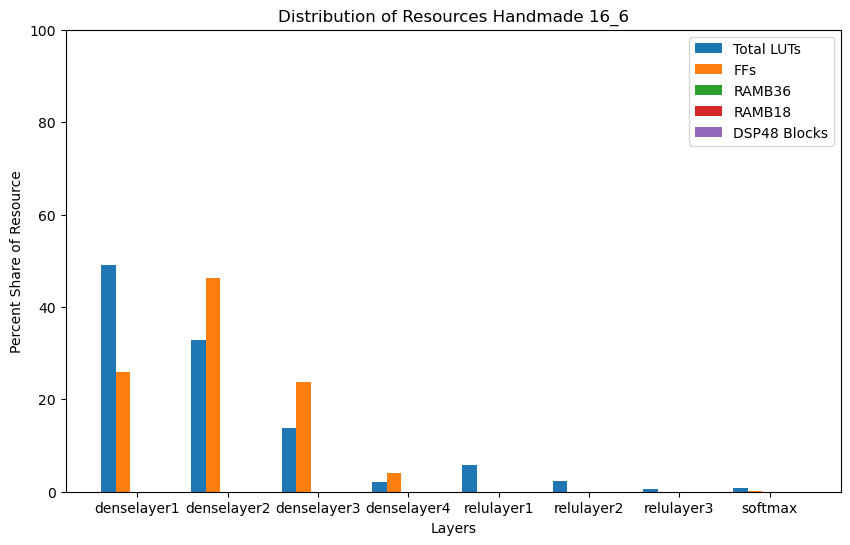

In [ ]:
import re
maps = "Total LUTs | Logic LUTs | LUTRAMs | SRLs |  FFs | RAMB36 | RAMB18 | DSP48 Blocks"
pat = r".*?\s(\d+).*?\s\d+.*?\s\d+.*?\s\d+.*?\s(\d+).*?\s(\d+).*?\s(\d+).*?\s(\d+)"
# maps = maps.split(" | ")
# print(len(maps))
# for i in range(len(maps)):
#     pat = pat + r".*?\s(\d+)"
#pat = pat + r".*?(\d+)"
WIDTH = 16
NINT = 6
def extract_layers(file, layers):
    
    with open(file) as f:
        text = f.read()
    out = {}
    for layer in layers:
        m = re.search(layer + pat, text, re.IGNORECASE)
        new_layer = []
        i=1
        while True:
            try:
                new_layer.append(int(m.group(i)))
                i+=1
            except: break
        out[layer] = new_layer.copy()
    return out
layers = ["waiz_benchmark", "denselayer1", "denselayer2", "denselayer3", "denselayer4", "relulayer1", "relulayer2", "relulayer3", "softmax"]
output = extract_layers(f"../reports/{WIDTH}_{NINT}_hier_fx.rpt", layers)
import matplotlib.pyplot as plt
import numpy as np
maps = "Total LUTs | FFs | RAMB36 | RAMB18 | DSP48 Blocks"
maps = maps.split(" | ")
# Example data
data = output
keys = list(data.keys())[1:]
totals = data["waiz_benchmark"]
values = []
for key in keys:
    vals = data[key]
    new_vals = []
    for i, val in enumerate(vals):
        if (val>0):
            new_vals.append(100*(val/(totals[i])))
        else:
            new_vals.append(0)
    values.append(new_vals)
#values = list(data.values())

# Number of bars per group (length of list)
n_bars = len(values[0])
x = np.arange(len(keys))  # positions for each group

bar_width = 0.8 / n_bars  # distribute bars evenly within each group
res.figure(figsize=(10, 6))
# Plot each set of bars
for i in range(n_bars):
    res.bar(
        x + i * bar_width,
        [v[i] for v in values],
        width=bar_width,
        label = maps[i]
    )
plt.xticks(x + bar_width * (n_bars-1)/2, keys)
plt.ylabel('Percent Share of Resource')
plt.xlabel('Layers')
plt.ylim((0,100))
plt.title(f'Distribution of Resources Handmade {WIDTH}_{NINT}')
plt.legend()
#plt.xticks(np.arange(4, 26, 3))
plt.show()


{'myproject': [64830, 37461, 0, 4, 0], 'grp_dense_latency_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_1_fu_177': [15673, 7915, 0, 0, 0], 'grp_dense_latency_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_fu_103': [28940, 16131, 0, 0, 0], 'grp_dense_latency_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_s_fu_171': [14918, 7150, 0, 0, 0], 'grp_dense_latency_ap_fixed_ap_fixed_16_6_5_3_0_config14_0_0_0_0_0_0_fu_213': [2366, 1739, 0, 0, 0], 'grp_normalize_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_1_fu_249': [1342, 1024, 0, 0, 0], 'grp_normalize_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_2_fu_353': [750, 539, 0, 0, 0], 'grp_normalize_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_s_fu_317': [543, 516, 0, 0, 0], 'grp_softmax_stable_ap_fixed_ap_fixed_16_6_5_3_0_softmax_config16_s_fu_529': [185, 225, 0, 4, 0]}
[988, 68, 0, 0, 0] 
 [64830, 37461, 0, 4, 0]


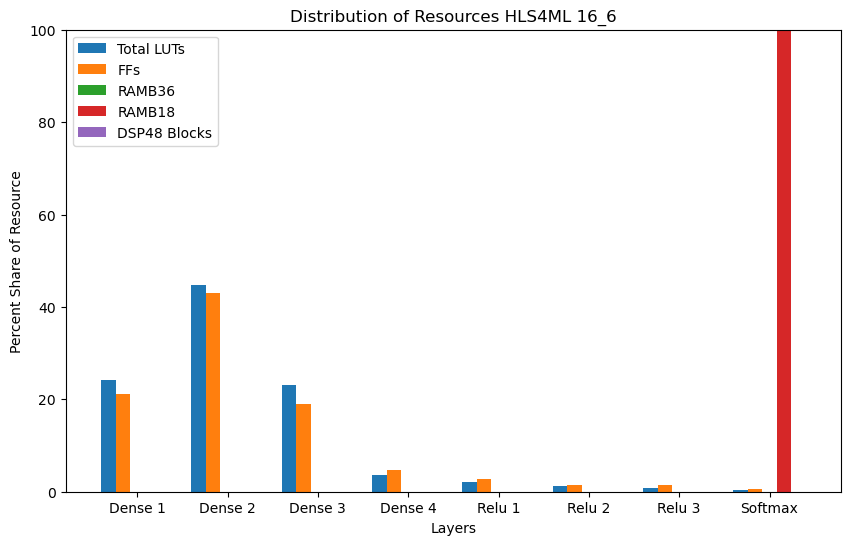

In [3]:
import re, numpy as np, matplotlib.pyplot as plt
maps = "Total LUTs | Logic LUTs | LUTRAMs | SRLs |  FFs | RAMB36 | RAMB18 | DSP48 Blocks"
pat = r"(\w+).*?\|.*?\|.*?\s(\d+).*?\s\d+.*?\s\d+.*?\s\d+.*?\s(\d+).*?\s(\d+).*?\s(\d+).*?\s(\d+)"
WIDTH = 16
NINT = 6
def extract_layers(file):
    
    with open(file) as f:
        text = f.read()
    out = {}
    
    matches = re.findall(pat, text)
    for match in matches:
        try:
            out[match[0]]
        except:
            out[match[0]] = [int(match[i]) for i in range(1,len(match))]
    return out
# layers = ["waiz_benchmark", "denselayer1", "denselayer2", "denselayer3", "denselayer4", "relulayer1", "relulayer2", "relulayer3", "softmax"]
output = extract_layers(f"./reports/hls_{WIDTH}_{NINT}_util_hier.rpt")
print(output)
# import matplotlib.pyplot as plt
# import numpy as np
maps = "Total LUTs | FFs | RAMB36 | RAMB18 | DSP48 Blocks"
maps = maps.split(" | ")
# # Example data
data = output
keys = list(data.keys())[1:]
totals = data["myproject"]
values = []
print(vals,"\n", totals)
for key in keys:
    vals = data[key]
    new_vals = []
    for i, val in enumerate(vals):
        if (val>0):
            new_vals.append(100*(val/(totals[i])))
        else:
            new_vals.append(0)
    values.append(new_vals)
#values = list(data.values())

# Number of bars per group (length of list)
n_bars = len(values[0])
x = np.arange(len(keys))  # positions for each group

bar_width = 0.8 / n_bars  # distribute bars evenly within each group
plt.figure(figsize=(10, 6))
# Plot each set of bars

for i in range(n_bars):
    plt.bar(
        x + i * bar_width,
        [v[i] for v in values],
        width=bar_width,
        label = maps[i]
    )
labels = ["Dense 1", "Dense 2", "Dense 3", "Dense 4", "Relu 1", "Relu 2", "Relu 3", "Softmax"]
plt.xticks(x + bar_width * (n_bars-1)/2, labels)
plt.ylabel('Percent Share of Resource')
plt.xlabel('Layers')
plt.ylim((0,100))
plt.title(f'Distribution of Resources HLS4ML {WIDTH}_{NINT}')
plt.legend()
#plt.xticks(np.arange(4, 26, 3))
plt.show()


In [2]:
ans = np.load("y_test.npy")
print(ans[0:10])

[[0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]]
